In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imdlib
import jax

In [2]:
imd_jun23_forecast = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/imd_tigge_2023_07.grib')
imd_jun23_forecast

/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


<xarray.Dataset> Size: 290MB
Dimensions:     (time: 31, step: 9, latitude: 361, longitude: 720)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 248B 2023-07-01 2023-07-02 ... 2023-07-31
  * step        (step) timedelta64[ns] 72B 0 days 00:00:00 ... 2 days 00:00:00
    surface     float64 8B ...
  * latitude    (latitude) float64 3kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude   (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    valid_time  (time, step) datetime64[ns] 2kB ...
Data variables:
    tp          (time, step, latitude, longitude) float32 290MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             vabb
    GRIB_centreDescription:  New Delhi
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             New Delhi
    history:                 2025-06-24T20:54 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
jax.devices()

In [3]:
import imdlib as imd


start_yr = 2015
end_yr = 2016
variable = 'rain' # other options are ('tmin'/ 'tmax')
file_dir = "/Datastorage/saptarishi.dhanuka_asp25/imdlib_data/raw_imdlib"
data = imd.open_data(variable, start_yr, end_yr, 'yearwise', file_dir+'/rain/')
ds = data.get_xarray()
ds

<xarray.Dataset> Size: 102MB
Dimensions:  (time: 731, lat: 129, lon: 135)
Coordinates:
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
  * time     (time) datetime64[ns] 6kB 2015-01-01 2015-01-02 ... 2016-12-31
Data variables:
    rain     (time, lat, lon) float64 102MB -999.0 -999.0 ... -999.0 -999.0
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2025-06-05 15:06:34.183897 Python
    references:   
    comment:      
    crs:          epsg:4326

In [4]:
ds_july2015_orig = ds.sel(time=slice('2015-07-01', '2015-07-31'))
ds_july2015_orig = ds_july2015_orig.where(ds_july2015_orig['rain'] != -999.) #Remove NaN values
ds_july2015_orig

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 31, lat: 129, lon: 135)
Coordinates:
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
  * time     (time) datetime64[ns] 248B 2015-07-01 2015-07-02 ... 2015-07-31
Data variables:
    rain     (time, lat, lon) float64 4MB nan nan nan nan ... nan nan nan nan
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2025-06-05 15:06:34.183897 Python
    references:   
    comment:      
    crs:          epsg:4326

In [5]:
old_lats = ds_july2015_orig['lat'].values
old_lons = ds_july2015_orig['lon'].values
new_lats = np.arange(6.0, 39.0 + 1e-8, 1.0)
new_lats = np.flip(new_lats)
new_lons = np.arange(66, 100 + 1e-8, 1.0)
ds_july2015 = ds_july2015_orig.interp({'lat': new_lats, 'lon': new_lons}, 
                        method='linear',
                        kwargs={'fill_value': None})
ds_july2015

<xarray.Dataset> Size: 296kB
Dimensions:  (time: 31, lat: 34, lon: 35)
Coordinates:
  * time     (time) datetime64[ns] 248B 2015-07-01 2015-07-02 ... 2015-07-31
  * lat      (lat) float64 272B 39.0 38.0 37.0 36.0 35.0 ... 9.0 8.0 7.0 6.0
  * lon      (lon) float64 280B 66.0 67.0 68.0 69.0 ... 97.0 98.0 99.0 100.0
Data variables:
    rain     (time, lat, lon) float64 295kB nan nan nan nan ... nan nan nan nan
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2025-06-05 15:06:34.183897 Python
    references:   
    comment:      
    crs:          epsg:4326

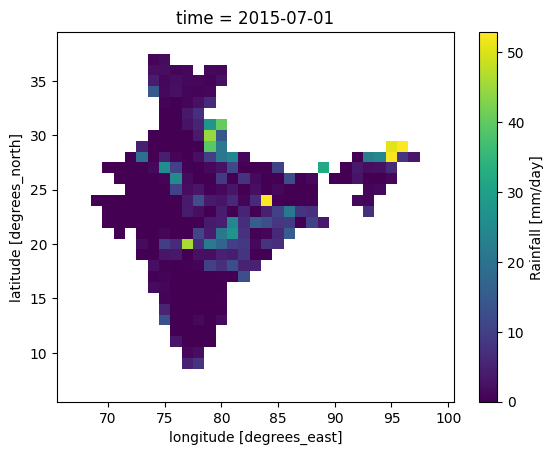

In [6]:
ds_july2015.isel(time=0)['rain'].plot()

In [7]:
ds_july2015.time.values

array(['2015-07-01T00:00:00.000000000', '2015-07-02T00:00:00.000000000',
       '2015-07-03T00:00:00.000000000', '2015-07-04T00:00:00.000000000',
       '2015-07-05T00:00:00.000000000', '2015-07-06T00:00:00.000000000',
       '2015-07-07T00:00:00.000000000', '2015-07-08T00:00:00.000000000',
       '2015-07-09T00:00:00.000000000', '2015-07-10T00:00:00.000000000',
       '2015-07-11T00:00:00.000000000', '2015-07-12T00:00:00.000000000',
       '2015-07-13T00:00:00.000000000', '2015-07-14T00:00:00.000000000',
       '2015-07-15T00:00:00.000000000', '2015-07-16T00:00:00.000000000',
       '2015-07-17T00:00:00.000000000', '2015-07-18T00:00:00.000000000',
       '2015-07-19T00:00:00.000000000', '2015-07-20T00:00:00.000000000',
       '2015-07-21T00:00:00.000000000', '2015-07-22T00:00:00.000000000',
       '2015-07-23T00:00:00.000000000', '2015-07-24T00:00:00.000000000',
       '2015-07-25T00:00:00.000000000', '2015-07-26T00:00:00.000000000',
       '2015-07-27T00:00:00.000000000', '2015-07-28

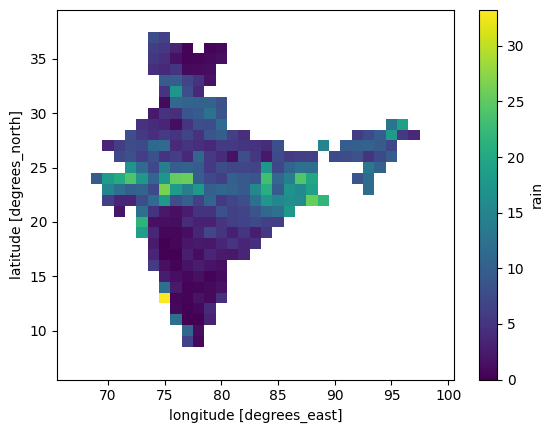

In [8]:
ds_clean = ds_july2015.where(ds_july2015['rain'] != -999.) #Remove NaN values
ds_clean['rain'].mean('time').plot()

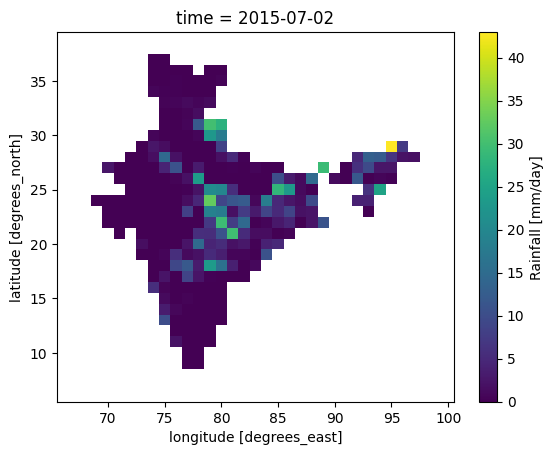

In [9]:
ds_clean['rain'].isel(time=1).plot()

In [10]:
imerg_test = xr.open_dataset("/Datastorage/saptarishi.dhanuka_asp25/era5_imerg_20150701-2015_india_full_globe.nc").sel(time=slice('2015-07-01', '2015-07-31'))
imerg_test = imerg_test.rename({'latitude': 'lat', 'longitude': 'lon'})
print(imerg_test)

<xarray.Dataset> Size: 7GB
Dimensions:                  (time: 124, lat: 181, lon: 360, level: 37)
Coordinates:
  * lat                      (lat) float32 724B -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lon                      (lon) float32 1kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * time                     (time) datetime64[ns] 992B 2015-07-01 ... 2015-0...
Data variables: (12/13)
    10m_u_component_of_wind  (time, lat, lon) float32 32MB ...
    10m_v_component_of_wind  (time, lat, lon) float32 32MB ...
    2m_temperature           (time, lat, lon) float32 32MB ...
    geopotential             (time, level, lat, lon) float32 1GB ...
    geopotential_at_surface  (lat, lon) float32 261kB ...
    land_sea_mask            (lat, lon) float32 261kB ...
    ...                       ...
    specific_humidity        (time, level, lat, lon) float32 1GB ...
    temperature              (time, level, lat, lon) float32 1GB .

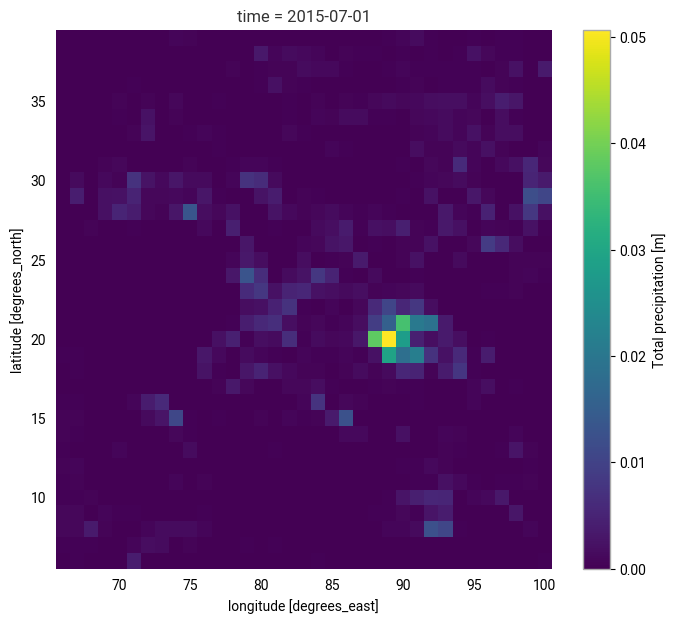

In [11]:
imerg_test.isel(time=0)['total_precipitation_6hr'].sel(lat=slice(6, 39), lon=slice(66, 100)).plot()

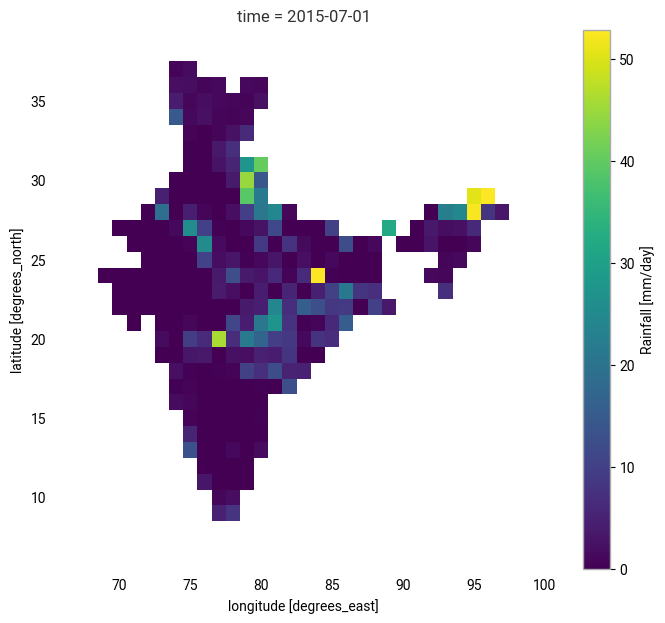

In [12]:
india_processed = ds_july2015.copy(deep=True)
india_processed.isel(time=0)['rain'].plot()

In [13]:
# --- 2. Preprocess ds_july2015 ---

conversion_factor = 4000.0 # (mm/day) to (m/6hr)
india_processed['rain'] = india_processed['rain'] / conversion_factor
india_processed = india_processed.rename({'rain': 'total_precipitation_6hr'})
india_processed = india_processed.sortby('lat') # Sort lat to ascending
india_processed.coords['time'] = india_processed.time.dt.floor('D')
unique_daily_source_times = np.unique(india_processed.time.values)
unique_daily_source_times

array(['2015-07-01T00:00:00.000000000', '2015-07-02T00:00:00.000000000',
       '2015-07-03T00:00:00.000000000', '2015-07-04T00:00:00.000000000',
       '2015-07-05T00:00:00.000000000', '2015-07-06T00:00:00.000000000',
       '2015-07-07T00:00:00.000000000', '2015-07-08T00:00:00.000000000',
       '2015-07-09T00:00:00.000000000', '2015-07-10T00:00:00.000000000',
       '2015-07-11T00:00:00.000000000', '2015-07-12T00:00:00.000000000',
       '2015-07-13T00:00:00.000000000', '2015-07-14T00:00:00.000000000',
       '2015-07-15T00:00:00.000000000', '2015-07-16T00:00:00.000000000',
       '2015-07-17T00:00:00.000000000', '2015-07-18T00:00:00.000000000',
       '2015-07-19T00:00:00.000000000', '2015-07-20T00:00:00.000000000',
       '2015-07-21T00:00:00.000000000', '2015-07-22T00:00:00.000000000',
       '2015-07-23T00:00:00.000000000', '2015-07-24T00:00:00.000000000',
       '2015-07-25T00:00:00.000000000', '2015-07-26T00:00:00.000000000',
       '2015-07-27T00:00:00.000000000', '2015-07-28

In [14]:

latmax = 38
latmin = 6
lonmin = 68
lonmax = 98

In [15]:


# --- 3. Create the 6-hourly override data from daily ds_july2015 ---
# This will have the spatial extent of ds_july2015 and 6-hourly times present in imerg_test
override_data_slices = []
for daily_time_np64 in unique_daily_source_times:
    daily_time_pd = pd.Timestamp(daily_time_np64)
    source_data_for_day = india_processed['total_precipitation_6hr'].sel(time=daily_time_pd)
    day_start_time = daily_time_pd
    day_end_time = daily_time_pd + pd.Timedelta(days=1) - pd.Timedelta(nanoseconds=1)
    target_times_for_day = imerg_test.time.sel(time=slice(day_start_time, day_end_time))

    if target_times_for_day.size > 0:
        expanded_slice = source_data_for_day.expand_dims(time=target_times_for_day.values)
        override_data_slices.append(expanded_slice)

# This is the data we want to use for replacement. It's defined ONLY on ds_july2015's
# spatial grid and for the 6-hourly timesteps corresponding to days in ds_july2015.
if not override_data_slices:
    print("No overlapping time periods found. Target dataset remains unchanged.")
    # In a real scenario, you might exit or handle this case as needed.
    full_override_data = None
else:
    full_override_data = xr.concat(override_data_slices, dim='time')

# --- 4. Update imerg_test using xr.where for precision ---
imerg_test_updated = imerg_test.copy(deep=True)


In [16]:
assert full_override_data is not None

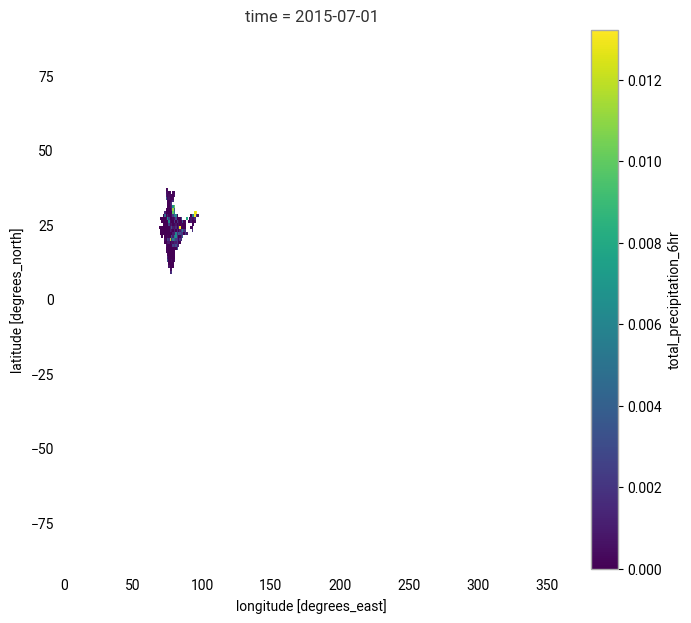

In [28]:
# Get the original precipitation data from the target
original_precip_in_target = imerg_test_updated['total_precipitation_6hr']

# Reindex full_override_data to match the entire grid of original_precip_in_target.
# This introduces NaNs in `override_aligned_to_target_grid` where full_override_data
# didn't have data (i.e., outside the spatial/temporal footprint of ds_july2015).
override_aligned_to_target_grid = full_override_data.reindex_like(original_precip_in_target)
override_aligned_to_target_grid.isel(time=0).plot()

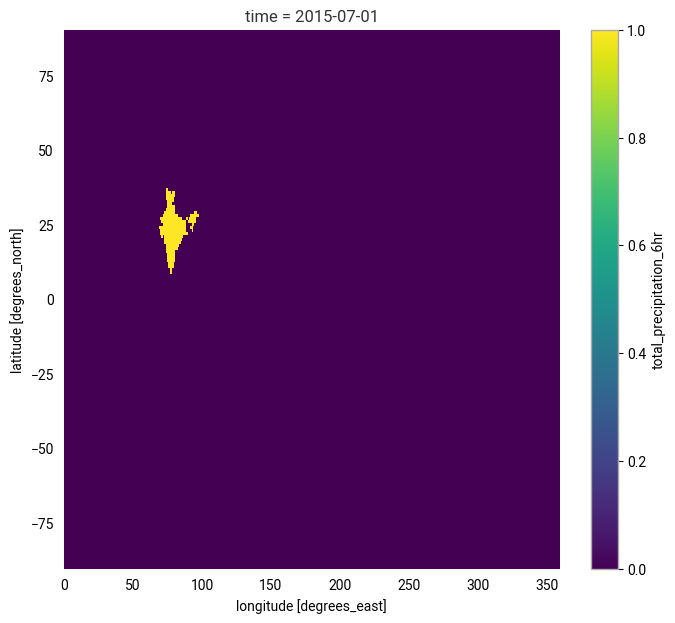

In [18]:
override_aligned_to_target_grid.isel(time=0).notnull().plot()

In [19]:
override_aligned_to_target_grid1, original_precip_in_target1 = xr.align(override_aligned_to_target_grid, original_precip_in_target, join='exact')

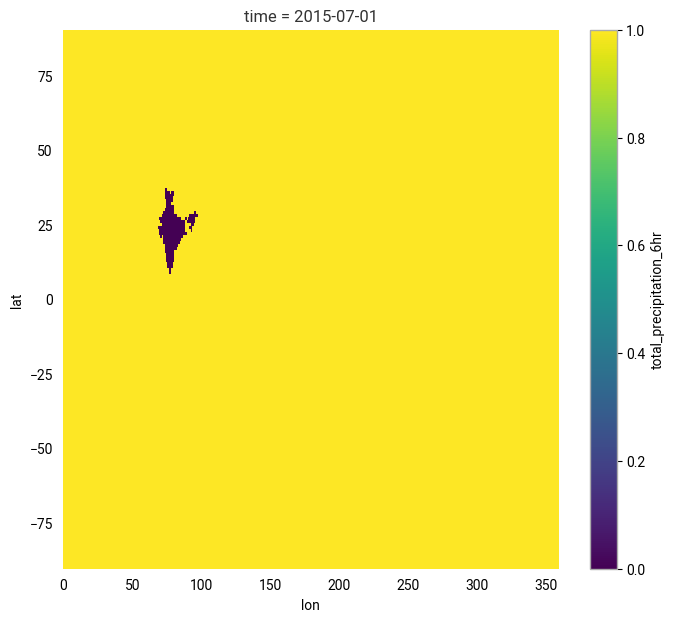

In [24]:
override_aligned_to_target_grid1.isel(time=0).isnull().plot()

In [21]:

# Where override_aligned_to_target_grid is not  NaN (i.e., has a valid value from ds_july2015), use it.
# Otherwise (i.e., outside ds_july2015 footprint, or if ds_july2015.rain itself was NaN),
# keep the value from original_precip_in_target.
updated_precip_data = xr.where(
    override_aligned_to_target_grid1.isnull(), # Condition
    original_precip_in_target1,                  # Where False: use old value
    override_aligned_to_target_grid1           # Where True: use new value
)

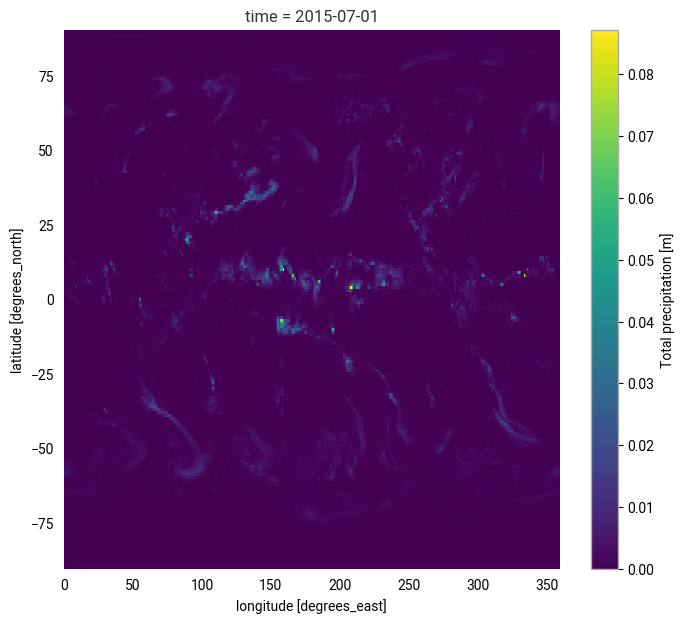

In [27]:
original_precip_in_target1.isel(time=0).plot()

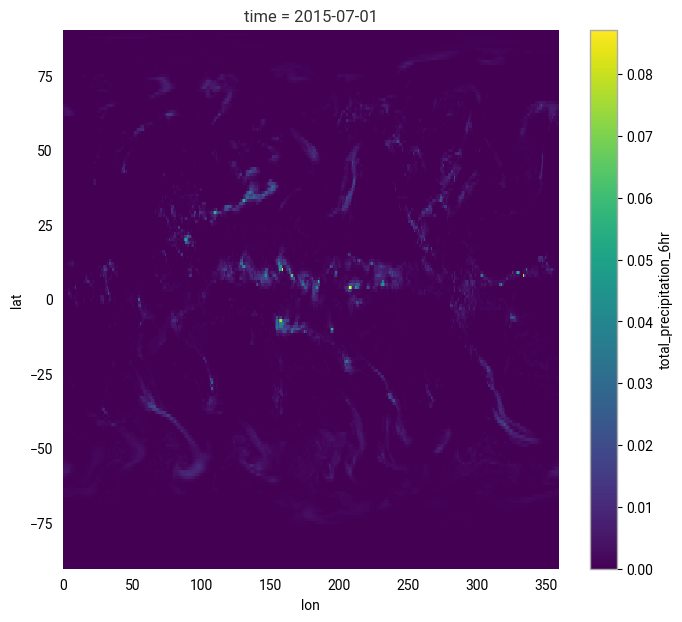

In [25]:
updated_precip_data.isel(time=0).plot()

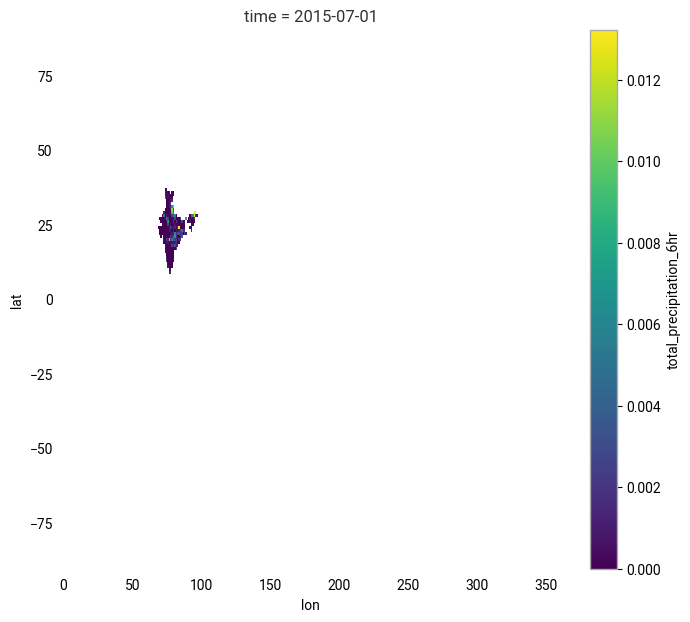

In [26]:
override_aligned_to_target_grid1.isel(time=0).plot()

In [ ]:

imerg_test_updated['total_precipitation_6hr'] = updated_precip_data

In [19]:

# Where override_aligned_to_target_grid is not NaN (i.e., has a valid value from ds_july2015), use it.
# Otherwise (i.e., outside ds_july2015 footprint, or if ds_july2015.rain itself was NaN),
# keep the value from original_precip_in_target.
updated_precip_data = xr.where(
    override_aligned_to_target_grid.notnull(), # Condition
    override_aligned_to_target_grid,           # Where True: use new value
    original_precip_in_target                  # Where False: use old value
)
imerg_test_updated['total_precipitation_6hr'] = updated_precip_data

In [20]:

if full_override_data is not None:
    # Get the original precipitation data from the target
    original_precip_in_target = imerg_test_updated['total_precipitation_6hr']

    # Reindex full_override_data to match the entire grid of original_precip_in_target.
    # This introduces NaNs in `override_aligned_to_target_grid` where full_override_data
    # didn't have data (i.e., outside the spatial/temporal footprint of ds_july2015).
    override_aligned_to_target_grid = full_override_data.reindex_like(original_precip_in_target)
    
    # Where override_aligned_to_target_grid is not NaN (i.e., has a valid value from ds_july2015), use it.
    # Otherwise (i.e., outside ds_july2015 footprint, or if ds_july2015.rain itself was NaN),
    # keep the value from original_precip_in_target.
    updated_precip_data = xr.where(
        override_aligned_to_target_grid.notnull(), # Condition
        override_aligned_to_target_grid,           # Where True: use new value
        original_precip_in_target                  # Where False: use old value
    )
    imerg_test_updated['total_precipitation_6hr'] = updated_precip_data
else:
    print("full_override_data is None, no update performed.")


In [21]:


# --- 5. Verification ---
print("\n--- imerg_test after update ---")

# Test Case 1: Point updated by ds_july2015
test_lat_in, test_lon_in = 25.0, 80.0
test_day_str_in = '2015-07-02'
test_day_ts_in = pd.Timestamp(test_day_str_in)
original_value_mm_day = ds_july2015.sel(time=test_day_ts_in, lat=test_lat_in, lon=test_lon_in, method='nearest').rain.item()
expected_value_m_6hr = original_value_mm_day / conversion_factor
print(f"\nVERIFICATION CASE 1: Point INSIDE ds_july2015 bounds ({test_lat_in}N, {test_lon_in}E on {test_day_str_in})")
print(f"Original source value: {original_value_mm_day} mm/day. Expected in target: {expected_value_m_6hr:.6f} m/6hr")
for hr_offset in [0, 6, 12, 18]:
    target_time_check = test_day_ts_in + pd.Timedelta(hours=hr_offset)
    if target_time_check in imerg_test_updated.time:
        val = imerg_test_updated.sel(time=target_time_check, lat=test_lat_in, lon=test_lon_in).total_precipitation_6hr.item()
        print(f"  Value at {target_time_check}: {val:.6f} m/6hr")
        assert np.isclose(val, expected_value_m_6hr), f"Mismatch: {val} != {expected_value_m_6hr}"

# Test Case 2: Point OUTSIDE ds_july2015 spatial bounds (should be unchanged)
# ds_july2015 lat min is 6.0. Let's pick 5.0.
# ds_july2015 lon min is 66.0. Let's pick 65.0.
outside_lat, outside_lon = 5.0, 80.0 # Lat is outside
target_time_check_outside = pd.Timestamp('2015-07-02 00:00:00') # A time covered by ds_july2015
print(f"\nVERIFICATION CASE 2: Point OUTSIDE ds_july2015 spatial bounds ({outside_lat}N, {outside_lon}E at {target_time_check_outside})")
if outside_lat in imerg_test_updated.lat and outside_lon in imerg_test_updated.lon:
    val_outside_spatial = imerg_test_updated.sel(time=target_time_check_outside, lat=outside_lat, lon=outside_lon).total_precipitation_6hr.item()
    print(f"  Value: {val_outside_spatial:.6f} m/6hr. Expected: {-1:.6f} m/6hr (initial imerg_test value)")
    # assert np.isclose(val_outside_spatial, -1), "Value outside spatial bounds was unexpectedly changed."
else:
    print(f"  Coordinate ({outside_lat}, {outside_lon}) not found directly in imerg_test for exact check.")


# Test Case 3: Point OUTSIDE ds_july2015 temporal bounds (should be unchanged)
# ds_july2015 times are July 1,2,3,30. Let's pick July 5th.
outside_time_str = '2015-07-05 00:00:00'
within_spatial_lat, within_spatial_lon = 25.0, 80.0 # A point spatially within ds_july2015
print(f"\nVERIFICATION CASE 3: Point OUTSIDE ds_july2015 temporal bounds ({within_spatial_lat}N, {within_spatial_lon}E at {outside_time_str})")
if pd.Timestamp(outside_time_str) in imerg_test_updated.time:
    val_outside_temporal = imerg_test_updated.sel(time=outside_time_str, lat=within_spatial_lat, lon=within_spatial_lon).total_precipitation_6hr.item()
    print(f"  Value: {val_outside_temporal:.6f} m/6hr. Expected: {-1:.6f} m/6hr")
    # assert np.isclose(val_outside_temporal, -1), "Value outside temporal bounds was unexpectedly changed."
else:
    print(f"  Time {outside_time_str} not in imerg_test_updated for verification.")

# Test Case 4: Point where original ds_july2015.rain was NaN (should preserve target value)
nan_source_lat, nan_source_lon = 39.0, 66.0 # Corresponds to ds_july2015.lat[0], lon[0] after sorting
nan_source_time = pd.Timestamp('2015-07-01 00:00:00')
print(f"\nVERIFICATION CASE 4: Point where ds_july2015.rain was NaN ({nan_source_lat}N, {nan_source_lon}E at {nan_source_time})")
original_india_val_at_nan = ds_july2015.sel(time=pd.Timestamp('2015-07-01'), lat=39.0, lon=66.0).rain.item() # Original lat before sort
print(f"  Original ds_july2015.rain at this point (before conversion): {original_india_val_at_nan}")
assert np.isnan(original_india_val_at_nan), "Source data for NaN test point is not NaN!"

val_at_nan_loc = imerg_test_updated.sel(time=nan_source_time, lat=nan_source_lat, lon=nan_source_lon).total_precipitation_6hr.item()
print(f"  Value in updated target: {val_at_nan_loc:.6f} m/6hr. Expected: {-999:.6f} m/6hr (original target value at this specific point)")
# assert np.isclose(val_at_nan_loc, -999), "Value at source NaN location was not preserved from original imerg_test."


print("\nSuccessfully updated imerg_test. `imerg_test_updated` contains the result.")
# print("\nFinal check on a slice of imerg_test_updated:")
# print(imerg_test_updated['total_precipitation_6hr'].sel(time='2015-07-02 00:00:00', lat=slice(30,20), lon=slice(75,85)))


--- imerg_test after update ---

VERIFICATION CASE 1: Point INSIDE ds_july2015 bounds (25.0N, 80.0E on 2015-07-02)
Original source value: 19.720537185668945 mm/day. Expected in target: 0.004930 m/6hr
  Value at 2015-07-02 00:00:00: 0.004930 m/6hr
  Value at 2015-07-02 06:00:00: 0.004930 m/6hr
  Value at 2015-07-02 12:00:00: 0.004930 m/6hr
  Value at 2015-07-02 18:00:00: 0.004930 m/6hr

VERIFICATION CASE 2: Point OUTSIDE ds_july2015 spatial bounds (5.0N, 80.0E at 2015-07-02 00:00:00)
  Value: 0.000078 m/6hr. Expected: -1.000000 m/6hr (initial imerg_test value)

VERIFICATION CASE 3: Point OUTSIDE ds_july2015 temporal bounds (25.0N, 80.0E at 2015-07-05 00:00:00)
  Value: 0.000000 m/6hr. Expected: -1.000000 m/6hr

VERIFICATION CASE 4: Point where ds_july2015.rain was NaN (39.0N, 66.0E at 2015-07-01 00:00:00)
  Original ds_july2015.rain at this point (before conversion): nan
  Value in updated target: 0.000000 m/6hr. Expected: -999.000000 m/6hr (original target value at this specific point

In [63]:
imerg_test_updated.to_netcdf("/Datastorage/saptarishi.dhanuka_asp25/era5_imerg_20150701-2015_india_full_globe_updated1.nc")

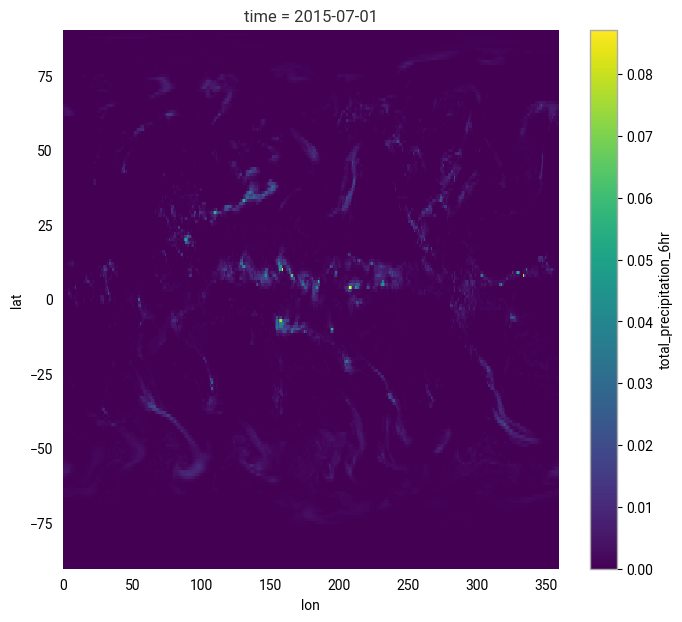

In [22]:
imerg_test_updated.isel(time=0).total_precipitation_6hr.plot()

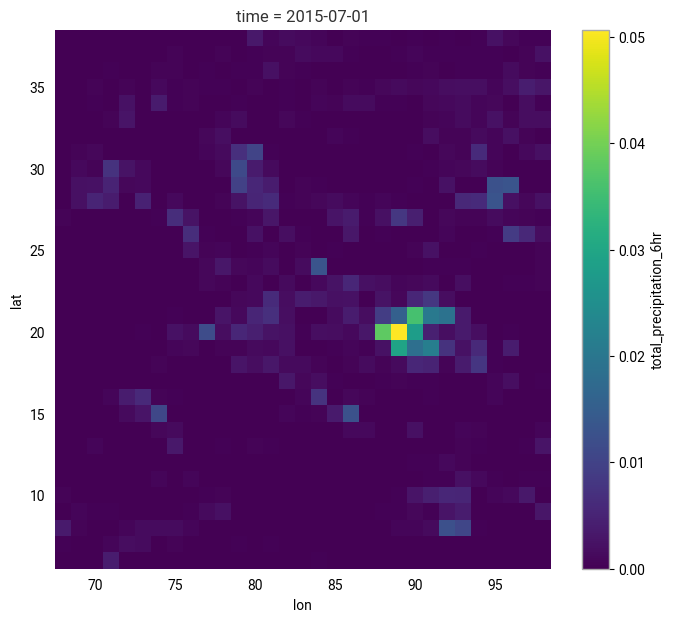

In [ ]:


imerg_test_updated.isel(time=0).total_precipitation_6hr.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).plot()

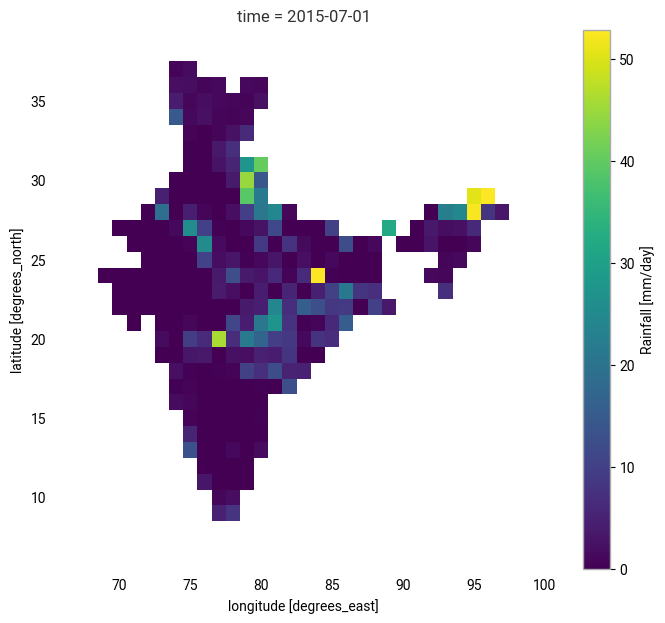

In [22]:
ds_july2015.isel(time=0)['rain'].plot()

In [ ]:
import cartopy.crs as ccrs
from datetime import datetime
current_date = datetime.now().strftime("%Y-%m-%d_%H-%M")

#iterates over the initialization of the model
for i in tqdm(range(4)):
    predictions_old = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india2015_2015_{i}.nc")
    predictions_finetuned = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2015_full_2015_{i}_imerg.nc")
    eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
    select_time_evals_copy[i].load(), target_lead_times=slice("6h", "168h"),
    **dataclasses.asdict(task_config))

    init_date = select_time_evals_copy[i].datetime.values[0][0]
    init_date = init_date.astype('datetime64[D]')
    imd_july_2022_temp = imd_july_2022.sel(time=init_date)

    variable_name = 'total_precipitation_6hr'
    
    # Plot differences with ground truth for each time step
    differences_finetuned = []
    differences_base = []
    differences_era5_imd = []
    for time_step in tqdm(range(4)):
        differences_finetuned.append(plot_difference_with_targets_fine_sims(predictions_finetuned,eval_targets,time_step, variable_name))
        differences_base.append(plot_difference_with_targets_base_sims(predictions_old,eval_targets,time_step, variable_name))
        imd_6h_converted = (imd_july_2022_temp.isel(step=time_step+1)['tp'] - imd_july_2022_temp.isel(step=time_step)['tp'])/1000
        differences_era5_imd.append(plot_diff_imd_era5_sims(imd_6h_converted,eval_targets,time_step, variable_name))

    # print(differences_finetuned)
    # print(differences_base)

    # print("Finetuned differences: ", differences_finetuned)
    # print("Base differences: ", differences_base)
    


    def compute_mse(predictions, targets):
        return ((predictions - targets) ** 2).mean()

    def compute_mse_diffs(diff):
        return (diff ** 2).mean(dim=["lat", "lon"]).values

    # Compute the MSE for each time step and aggregate
    mse_finetuned = []
    mse_base = []
    mse_imd_era5 = []
    for diff_counter in range(len(differences_finetuned)):
        mse_diff_finetuned = compute_mse_diffs(differences_finetuned[diff_counter])
        mse_diff_base = compute_mse_diffs(differences_base[diff_counter])
        mse_diff_imd_era5 = compute_mse_diffs(differences_era5_imd[diff_counter])
        
        mse_finetuned.append(mse_diff_finetuned)
        mse_base.append(mse_diff_base)
        mse_imd_era5.append(mse_diff_imd_era5)

    # print(mse_base)
    # print()
    # print(mse_finetuned)



    
    # Plot the line chart
    plt.figure(figsize=(10, 6))
    plt.plot(list(range(4)), mse_base, label='MSE Base', marker='o')
    plt.plot(list(range(4)), mse_finetuned, label='MSE Finetuned', marker='o')
    plt.plot(list(range(4)), mse_imd_era5, label='MSE IMD', marker='o')
    # plt.plot(time_steps, mse_imd_era5, label='MSE IMD ERA5', marker='x')

        # Annotate the first and last points for MSE Base
    # plt.annotate(f"{mse_base[0]:.4f}", (0, mse_base[0]), textcoords="offset points", xytext=(-10, 10), ha='center')
    # plt.annotate(f"{mse_base[-1]:.4f}", (6, mse_base[-1]), textcoords="offset points", xytext=(-10, 10), ha='center')


    # Add labels, title, and legend
    plt.xlabel('Time Step')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.title(f'MSE Comparison: Base vs Finetuned vs IMD relative to IMERG init at {select_time_evals_copy[i].datetime.values[0][0]} ')
    plt.legend()
    plt.grid(True)

    # Show the plot
    plt.show()
    # plt.savefig(f"./final_plots/metrics/mse_comparison_finetuned_base_{i}_{current_date}.png")
    plt.clf()


In [38]:
predictions_old = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_imerg_sept2015.nc")
predictions_finetuned = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2015_full_2015_3_imerg.nc")

/tmp/ipykernel_839428/61413266.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_old = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_imerg_sept2015.nc")
/tmp/ipykernel_839428/61413266.py:2: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_finetuned = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2015_full_2015_3_imerg.nc")


In [2]:
import imdlib as imd
tmax_data = imd.open_data('tmax', 2020, 2021,'yearwise', '/home/saptarishi.dhanuka_asp25/divij_graphcast_dir/tmax')
tmin_data = imd.open_data('tmin', 2020, 2021,'yearwise', '/home/saptarishi.dhanuka_asp25/divij_graphcast_dir/tmin')

In [3]:
tmax_data = tmax_data.get_xarray()
tmin_data = tmin_data.get_xarray()

In [ ]:
# combine the two datasets


In [4]:
combined_dataset_imd = xr.merge([tmin_data, tmax_data])
combined_dataset_imd


<xarray.Dataset> Size: 11MB
Dimensions:  (time: 731, lat: 31, lon: 31)
Coordinates:
  * lat      (lat) float64 248B 7.5 8.5 9.5 10.5 11.5 ... 34.5 35.5 36.5 37.5
  * lon      (lon) float64 248B 67.5 68.5 69.5 70.5 71.5 ... 94.5 95.5 96.5 97.5
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    tmin     (time, lat, lon) float64 6MB 99.9 99.9 99.9 99.9 ... 99.9 99.9 99.9
    tmax     (time, lat, lon) float64 6MB 99.9 99.9 99.9 99.9 ... 99.9 99.9 99.9
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2025-04-26 13:56:39.644519 Python
    references:   
    comment:      
    crs:          epsg:4326

In [14]:
tmax_data = tmax_data.rename({'time': 'base_time', 'tmax': '2m_temperature', 'lat': 'latitude', 'lon': 'longitude'})
tmin_data = tmin_data.rename({'time': 'base_time', 'tmin': '2m_temperature', 'lat': 'latitude', 'lon': 'longitude'})
threshold = 54

tmax_data['2m_temperature'] = tmax_data['2m_temperature'].where(tmax_data['2m_temperature'] <= threshold, tmax_data['2m_temperature'].where(tmax_data['2m_temperature'] <= threshold).mean())
tmin_data['2m_temperature'] = tmin_data['2m_temperature'].where(tmin_data['2m_temperature'] <= threshold, tmin_data['2m_temperature'].where(tmin_data['2m_temperature'] <= threshold).mean())



In [15]:
tmax_data

<xarray.Dataset> Size: 6MB
Dimensions:         (base_time: 731, latitude: 31, longitude: 31)
Coordinates:
  * latitude        (latitude) float64 248B 7.5 8.5 9.5 10.5 ... 35.5 36.5 37.5
  * longitude       (longitude) float64 248B 67.5 68.5 69.5 ... 95.5 96.5 97.5
  * base_time       (base_time) datetime64[ns] 6kB 2020-01-01 ... 2021-12-31
Data variables:
    2m_temperature  (base_time, latitude, longitude) float64 6MB 30.59 ... 30.59
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2025-04-26 06:47:01.154256 Python
    references:   
    comment:      
    crs:          epsg:4326

In [ ]:
tmax_data['2m_temperature'] += 273.15
tmin_data['2m_temperature'] += 273.15

In [10]:
tmax_data

<xarray.Dataset> Size: 6MB
Dimensions:         (base_time: 731, latitude: 31, longitude: 31)
Coordinates:
  * latitude        (latitude) float64 248B 7.5 8.5 9.5 10.5 ... 35.5 36.5 37.5
  * longitude       (longitude) float64 248B 67.5 68.5 69.5 ... 95.5 96.5 97.5
  * base_time       (base_time) datetime64[ns] 6kB 2020-01-01 ... 2021-12-31
Data variables:
    2m_temperature  (base_time, latitude, longitude) float64 6MB 303.7 ... 303.7
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2025-04-26 06:46:02.017067 Python
    references:   
    comment:      
    crs:          epsg:4326

In [ ]:
# combine the tmax and tmin data
tmax_data = tmax_data.rename({'2m_temperature': 'tmax'})

In [8]:
era5_test

<xarray.Dataset> Size: 655GB
Dimensions:                  (time: 11076, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
  * latitude                 (latitude) float32 724B -90.0 -89.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * longitude                (longitude) float32 1kB 0.0 1.0 2.0 ... 358.0 359.0
  * time                     (time) datetime64[ns] 89kB 2015-01-01 ... 2022-0...
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 3GB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 3GB ...
    2m_temperature           (time, latitude, longitude) float32 3GB ...
    geopotential             (time, level, latitude, longitude) float32 107GB ...
    geopotential_at_surface  (latitude, longitude) float32 261kB ...
    land_sea_mask            (latitude, longitude) float32 261kB ...
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 107GB ...
    temperature              (time, level, latitude, longitude) float32 107GB ...
    total_precipitation_6hr  (time, latitude, longitude) float32 3GB ...
    u_component_of_wind      (time, level, latitude, longitude) float32 107GB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 107GB ...
    vertical_velocity        (time, level, latitude, longitude) float32 107GB ...

In [5]:
import xarray as xr
import numpy as np
import pandas as pd
import logging
import xesmf as xe # Requires xesmf installation

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Define the value used for missing data in the IMD dataset
IMD_MISSING_VALUE = 99.9 # Based on the provided format example

def replace_era5_temp_with_imd_tmin_tmax(
    era5_target_data: xr.Dataset,
    imd_daily_temp: xr.Dataset,
    imd_tmax_var: str = 'tmax', # Variable name as per imd_format
    imd_tmin_var: str = 'tmin', # Variable name as per imd_format
    imd_temp_units: str = 'celsius', # Assume Celsius based on typical IMD data
    era5_temp_var: str = '2m_temperature',
    regrid_method: str = 'bilinear', # Suitable for temperature
    tmin_local_hour: float = 6.0,  # Estimated local time (0-24) for Tmin
    tmax_local_hour: float = 14.0, # Estimated local time (0-24) for Tmax
) -> xr.Dataset:
    """
    Replaces ERA5 6-hourly 2m temperature with values interpolated from daily
    IMD Tmax and Tmin data over the IMD domain.

    Handles coordinate differences, missing values (e.g., 99.9), spatial regridding,
    temporal interpolation (cosine), and unit conversion.

    Args:
        era5_target_data: ERA5 target dataset with 6-hourly '2m_temperature'.
                          Must have 'time', 'latitude' [asc], 'longitude' [0-360, asc].
        imd_daily_temp: IMD dataset with daily 'tmax' and 'tmin'.
                        Must have 'time' [daily], 'lat' [asc], 'lon' [asc].
        imd_tmax_var: Variable name for maximum temperature in imd_daily_temp.
        imd_tmin_var: Variable name for minimum temperature in imd_daily_temp.
        imd_temp_units: Units of Tmax/Tmin in imd_daily_temp ('celsius' or 'kelvin').
        era5_temp_var: Name of the 2m temperature variable in era5_target_data.
        regrid_method: Regridding method for xESMF (e.g., 'bilinear').
        tmin_local_hour: Approximate local time (0-24) when daily Tmin occurs.
        tmax_local_hour: Approximate local time (0-24) when daily Tmax occurs.

    Returns:
        A new xarray Dataset, a copy of era5_target_data, with era5_temp_var
        replaced by IMD-derived values within the IMD domain where data is valid.

    Raises:
        ValueError, ImportError, KeyError as appropriate.
    """
    logging.info(f"Starting replacement of '{era5_temp_var}' with IMD Tmin/Tmax data.")

    if not isinstance(xe, type(xe)):
         raise ImportError("The 'xesmf' library is required for regridding.")

    # --- 1. Input Validation ---
    for var in [imd_tmax_var, imd_tmin_var]:
        if var not in imd_daily_temp:
            raise ValueError(f"IMD variable '{var}' not found in imd_daily_temp.")
    if era5_temp_var not in era5_target_data:
        raise ValueError(f"ERA5 variable '{era5_temp_var}' not found.")
    # Coordinate checks
    for coord in ['time', 'latitude', 'longitude']:
        if coord not in era5_target_data.coords: raise KeyError(f"ERA5 missing coordinate '{coord}'.")
    for coord in ['time', 'lat', 'lon']:
        if coord not in imd_daily_temp.coords: raise KeyError(f"IMD missing coordinate '{coord}'.")

    # --- 2. Preprocess IMD Data ---
    logging.info("Preprocessing IMD temperature data...")
    imd_processed = imd_daily_temp[[imd_tmax_var, imd_tmin_var]].copy()

    # Rename coords to match ERA5 standard for easier processing downstream
    imd_processed = imd_processed.rename({'lat': 'latitude', 'lon': 'longitude'})

    # Replace missing value indicator with NaN BEFORE calculations/regridding
    logging.debug(f"Replacing IMD missing value indicator ({IMD_MISSING_VALUE}) with NaN.")
    # Use a small tolerance for float comparison
    missing_mask_tmax = abs(imd_processed[imd_tmax_var] - IMD_MISSING_VALUE) < 1e-5
    missing_mask_tmin = abs(imd_processed[imd_tmin_var] - IMD_MISSING_VALUE) < 1e-5
    imd_processed[imd_tmax_var] = imd_processed[imd_tmax_var].where(~missing_mask_tmax)
    imd_processed[imd_tmin_var] = imd_processed[imd_tmin_var].where(~missing_mask_tmin)
    logging.info(f"Replaced {missing_mask_tmax.sum().item()} missing Tmax values.")
    logging.info(f"Replaced {missing_mask_tmin.sum().item()} missing Tmin values.")


    # Unit Conversion (ensure Kelvin)
    if imd_temp_units.lower() == 'celsius':
        logging.debug("Converting IMD temperatures from Celsius to Kelvin.")
        imd_processed[imd_tmax_var] = imd_processed[imd_tmax_var] + 273.15
        imd_processed[imd_tmin_var] = imd_processed[imd_tmin_var] + 273.15
    elif imd_temp_units.lower() != 'kelvin':
        raise ValueError(f"Unsupported IMD temperature units: {imd_temp_units}")
    # Update attrs AFTER potential conversion
    imd_processed[imd_tmax_var].attrs['units'] = 'K'
    imd_processed[imd_tmin_var].attrs['units'] = 'K'

    # Ensure latitude and longitude are sorted ascending (ERA5 standard, needed for xESMF)
    # Based on format description, they already are, but sorting is safe.
    imd_processed = imd_processed.sortby(['latitude', 'longitude'])

    # Store original IMD bounds for masking later (use renamed coords)
    imd_lat_min = imd_processed['latitude'].min().item()
    imd_lat_max = imd_processed['latitude'].max().item()
    imd_lon_min = imd_processed['longitude'].min().item()
    imd_lon_max = imd_processed['longitude'].max().item()
    logging.info(f"IMD bounds for masking: Lat [{imd_lat_min:.2f}, {imd_lat_max:.2f}], Lon [{imd_lon_min:.2f}, {imd_lon_max:.2f}]")


    # --- 3. Spatial Regridding (IMD -> ERA5 grid) ---
    logging.info(f"Regridding IMD Tmin/Tmax to ERA5 grid using '{regrid_method}'...")
    # Target grid for regridding
    grid_out = xr.Dataset({
        'lat': era5_target_data['latitude'],
        'lon': era5_target_data['longitude']
    })
    # Source grid for regridding (needs 'lat'/'lon' names for xESMF)
    grid_in = xr.Dataset({
        'lat': imd_processed['latitude'],
        'lon': imd_processed['longitude']
    })

    try:
        regridder = xe.Regridder(grid_in, grid_out, regrid_method, reuse_weights=False)
        # Regrid both Tmin and Tmax together
        imd_regridded = regridder(imd_processed[[imd_tmax_var, imd_tmin_var]], keep_attrs=True)
        # Rename dimensions back to ERA5 standard
        print('IMD regridded dimensions:')
        print(imd_regridded.dims)
        # imd_regridded = imd_regridded.rename({'lat': 'latitude', 'lon': 'longitude'})
        # regridder.clean_weight_file() # Optional cleanup
    except Exception as e:
        logging.error(f"xESMF regridding failed: {e}")
        raise ValueError("Spatial regridding failed.") from e

    # --- 4. Temporal Alignment (Daily IMD -> 6-hourly ERA5) ---
    logging.info("Aligning daily regridded IMD data to 6-hourly ERA5 times...")
    target_times_6h = pd.to_datetime(era5_target_data['time'].values)

    # Ensure daily index for reindexing
    daily_times_for_reindex = pd.to_datetime(imd_regridded['time'].values).normalize()
    imd_regridded['time'] = daily_times_for_reindex

    # Forward fill Tmin and Tmax to 6-hourly timestamps
    imd_aligned_6h = imd_regridded.reindex(
        {'time': target_times_6h}, method='ffill'
    )

    # Check for NaNs introduced by ffill (if ERA5 starts before IMD)
    if imd_aligned_6h.isnull().any().any(): # Check across variables Tmin/Tmax
         logging.warning("NaNs found after temporal alignment (ffill). "
                         "This might indicate ERA5 time range starts before IMD. "
                         "These NaNs will be handled by masking.")

    # --- 5. Diurnal Cosine Interpolation ---
    logging.info("Performing cosine interpolation for 6-hourly temperatures...")
    tmin_6h = imd_aligned_6h[imd_tmin_var]
    tmax_6h = imd_aligned_6h[imd_tmax_var]
    era5_times_6h = imd_aligned_6h['time']
    # Use the target ERA5 longitudes for local time calculation
    era5_longitudes = era5_target_data['longitude']

    t_avg = (tmax_6h + tmin_6h) / 2.0
    t_amp = (tmax_6h - tmin_6h) / 2.0
    # Handle potential negative amplitudes (where tmin > tmax after regridding/NaNs)
    # Also handle cases where amplitude is NaN because one input was NaN
    t_amp = xr.where((t_amp < 0) | t_amp.isnull(), 0, t_amp)
    # If t_avg is NaN (both inputs were NaN), the result should also be NaN
    t_avg = t_avg.where(tmin_6h.notnull() | tmax_6h.notnull()) # Keep NaN if both were NaN


    # Calculate local time for each 6-hourly timestamp and ERA5 longitude
    utc_hour = era5_times_6h.dt.hour
    _, lon_broadcast = xr.broadcast(utc_hour, era5_longitudes) # Broadcast lon to match time, lat, lon
    local_time_of_day = (utc_hour + lon_broadcast / 15.0) % 24.0

    # Calculate the phase relative to Tmax time
    phase_rad = (local_time_of_day - tmax_local_hour) * (np.pi / 12.0)

    # Apply cosine interpolation using xr.apply_ufunc
    def cosine_interp(t_avg_pt, t_amp_pt, phase_rad_pt):
        # NaN propagation: if t_avg_pt is NaN, result is NaN
        return t_avg_pt + t_amp_pt * np.cos(phase_rad_pt)

    interpolated_temp_6h = xr.apply_ufunc(
        cosine_interp,
        t_avg,
        t_amp,
        phase_rad,
        dask="parallelized",
        output_dtypes=[t_avg.dtype]
    ).rename(era5_temp_var) # Give it the target variable name


    # --- 6. Create Mask ---
    logging.info("Creating mask for valid IMD data and spatial domain...")
    # Mask 1: Where interpolated value is NaN (due to original NaNs in Tmin or Tmax)
    missing_imd_mask = interpolated_temp_6h.isnull()
    num_missing = missing_imd_mask.sum().item()
    logging.info(f"Identified {num_missing} gridcell-times where interpolated IMD temp is NaN.")

    # Mask 2: Outside the original IMD spatial domain (use ERA5 coords for masking)
    era5_latitude = era5_target_data['latitude']
    era5_longitude = era5_target_data['longitude']
    spatial_mask = (
        (era5_latitude >= imd_lat_min) & (era5_latitude <= imd_lat_max) &
        (era5_longitude >= imd_lon_min) & (era5_longitude <= imd_lon_max)
    )
    _, spatial_mask_broadcast = xr.broadcast(interpolated_temp_6h, spatial_mask)
    logging.info(f"Spatial mask created covering IMD domain. Keeping {spatial_mask.sum().item()} ERA5 grid points.")

    # Combined Mask: True where we should *keep* the original ERA5 data
    keep_era5_mask = missing_imd_mask | (~spatial_mask_broadcast)
    num_to_replace = (~keep_era5_mask).sum().item()
    total_points = keep_era5_mask.size
    logging.info(f"Final mask determined. Replacing {num_to_replace}/{total_points} ({num_to_replace/total_points:.2%}) ERA5 temperature values.")


    # --- 7. Combine Data ---
    logging.info("Combining interpolated IMD data with original ERA5 data based on mask...")
    modified_era5_targets = era5_target_data.copy(deep=True)
    original_era5_temp = era5_target_data[era5_temp_var]

    # Align components before xr.where - crucial step
    aligned_interpolated_temp, aligned_keep_mask, aligned_original_temp = xr.align(
        interpolated_temp_6h,
        keep_era5_mask,
        original_era5_temp,
        join="exact" # Ensure perfect match of coords and dims
    )

    # Perform replacement
    final_temp = xr.where(
        aligned_keep_mask,
        aligned_original_temp,
        aligned_interpolated_temp # Use the NaN-containing interpolated value here
    )

    # Assign back and update attributes
    modified_era5_targets[era5_temp_var].data = final_temp.data
    modified_era5_targets[era5_temp_var].attrs['units'] = 'K' # Ensure unit is Kelvin
    modified_era5_targets[era5_temp_var].attrs['comment'] = (
        f"Partially replaced with 6hr temperature interpolated from daily IMD {imd_tmin_var}/"
        f"{imd_tmax_var} ({imd_temp_units}) within IMD domain ({imd_lat_min:.1f}-{imd_lat_max:.1f}N, "
        f"{imd_lon_min:.1f}-{imd_lon_max:.1f}E) using cosine model "
        f"(Tmin_hr={tmin_local_hour}, Tmax_hr={tmax_local_hour}) and '{regrid_method}' regridding. "
        "Original ERA5 value kept elsewhere or if IMD data missing."
    )

    logging.info("Temperature replacement complete.")
    return modified_era5_targets



In [6]:
# --- Example Usage ---

# Assume era5_test is loaded from the file as described
era5_test = xr.open_dataset("/Datastorage/saptarishi.dhanuka_asp25/era5_2015_2022-07-31T18_1deg_37levels.nc")

era5_temp_var = '2m_temperature'



# --- Run the replacement ---
try:
    print("\nRunning replacement function...")
    modified_era5 = replace_era5_temp_with_imd_tmin_tmax(
        era5_target_data=era5_test,
        imd_daily_temp=combined_dataset_imd,
        # imd_tmax_var='tmax', # Default is correct
        # imd_tmin_var='tmin', # Default is correct
        # imd_temp_units='celsius', # Default is correct
        regrid_method='bilinear',
        # target_utc_hours=[12] # Example: replace only at 12:00 UTC
    )
    print("\nReplacement function finished.")

    # --- Verification ---
    print("\nVerifying results...")
    # Select points inside and outside the IMD domain
    lat_in, lon_in = 20.0, 80.0 # Approx center of IMD
    lat_out, lon_out = 50.0, 10.0 # Outside IMD

    # Select times inside and outside the target hours
    time_in_window = pd.Timestamp('2020-01-02 12:00:00')
    time_out_window = pd.Timestamp('2020-01-02 06:00:00')

    # Check inside domain, inside time window (should be different)
    print(f"\n--- Point inside IMD ({lat_in}N, {lon_in}E), inside time window ({time_in_window}) ---")
    original_val_in_in = era5_test[era5_temp_var].sel(latitude=lat_in, longitude=lon_in, time=time_in_window, method='nearest').item()
    modified_val_in_in = modified_era5[era5_temp_var].sel(latitude=lat_in, longitude=lon_in, time=time_in_window, method='nearest').item()
    print(f"  Original ERA5: {original_val_in_in:.2f} K")
    print(f"  Modified (IMD): {modified_val_in_in:.2f} K")
    if not np.isclose(original_val_in_in, modified_val_in_in): print("  Values differ (expected).")
    else: print("  Values are the same (potential issue).")

    # Check inside domain, outside time window (should be same)
    print(f"\n--- Point inside IMD ({lat_in}N, {lon_in}E), outside time window ({time_out_window}) ---")
    original_val_in_out = era5_test[era5_temp_var].sel(latitude=lat_in, longitude=lon_in, time=time_out_window, method='nearest').item()
    modified_val_in_out = modified_era5[era5_temp_var].sel(latitude=lat_in, longitude=lon_in, time=time_out_window, method='nearest').item()
    print(f"  Original ERA5: {original_val_in_out:.2f} K")
    print(f"  Modified (ERA5): {modified_val_in_out:.2f} K")
    if np.isclose(original_val_in_out, modified_val_in_out): print("  Values match (expected).")
    else: print("  Values differ (potential issue).")

    # Check outside domain, inside time window (should be same)
    print(f"\n--- Point outside IMD ({lat_out}N, {lon_out}E), inside time window ({time_in_window}) ---")
    original_val_out_in = era5_test[era5_temp_var].sel(latitude=lat_out, longitude=lon_out, time=time_in_window, method='nearest').item()
    modified_val_out_in = modified_era5[era5_temp_var].sel(latitude=lat_out, longitude=lon_out, time=time_in_window, method='nearest').item()
    print(f"  Original ERA5: {original_val_out_in:.2f} K")
    print(f"  Modified (ERA5): {modified_val_out_in:.2f} K")
    if np.isclose(original_val_out_in, modified_val_out_in): print("  Values match (expected).")
    else: print("  Values differ (potential issue).")

    # Check point/time affected by missing IMD value (should be same)
    missing_imd_time = pd.Timestamp('2020-01-01 12:00:00') # Tmin was NaN this day, affects interp
    missing_imd_lat, missing_imd_lon = 10.5, 70.5 # Corresponds to [:, 5:10, 5:10] approx
    print(f"\n--- Point near missing IMD ({missing_imd_lat}N, {missing_imd_lon}E), affected time ({missing_imd_time}) ---")
    original_val_missing = era5_test[era5_temp_var].sel(latitude=missing_imd_lat, longitude=missing_imd_lon, time=missing_imd_time, method='nearest').item()
    modified_val_missing = modified_era5[era5_temp_var].sel(latitude=missing_imd_lat, longitude=missing_imd_lon, time=missing_imd_time, method='nearest').item()
    print(f"  Original ERA5: {original_val_missing:.2f} K")
    print(f"  Modified (ERA5): {modified_val_missing:.2f} K")
    if np.isclose(original_val_missing, modified_val_missing): print("  Values match (expected due to missing IMD).")
    else: print("  Values differ (potential issue in NaN handling).")


    # Verify other variables are untouched
    print("\nChecking if other variables are untouched:")
    xr.testing.assert_identical(era5_test['total_precipitation_6hr'], modified_era5['total_precipitation_6hr'])
    print("Other variables verified.")

except ImportError as e:
    print(f"\nError: {e}. Please install xesmf and its dependencies.")
except (ValueError, KeyError) as e:
    print(f"\nError during processing: {e}")
except Exception as e:
    print(f"\nAn unexpected error occurred: {e}")
    raise # Reraise unexpected errors for debugging


2025-04-26 19:26:45,817 - INFO - Starting replacement of '2m_temperature' with IMD Tmin/Tmax data.
2025-04-26 19:26:45,817 - INFO - Preprocessing IMD temperature data...


2025-04-26 19:26:45,827 - INFO - Replaced 443373 missing Tmax values.
2025-04-26 19:26:45,828 - INFO - Replaced 443237 missing Tmin values.
2025-04-26 19:26:45,842 - INFO - IMD bounds for masking: Lat [7.50, 37.50], Lon [67.50, 97.50]
2025-04-26 19:26:45,842 - INFO - Regridding IMD Tmin/Tmax to ERA5 grid using 'bilinear'...



Running replacement function...


2025-04-26 19:26:46,666 - INFO - Aligning daily regridded IMD data to 6-hourly ERA5 times...


IMD regridded dimensions:
FrozenMappingWarningOnValuesAccess({'time': 731, 'latitude': 181, 'longitude': 360})


2025-04-26 19:26:53,635 - WARNING - NaNs found after temporal alignment (ffill). This might indicate ERA5 time range starts before IMD. These NaNs will be handled by masking.
2025-04-26 19:26:53,637 - INFO - Performing cosine interpolation for 6-hourly temperatures...
2025-04-26 19:27:11,494 - INFO - Creating mask for valid IMD data and spatial domain...
2025-04-26 19:27:12,491 - INFO - Identified 478254140 gridcell-times where interpolated IMD temp is NaN.
2025-04-26 19:27:12,496 - INFO - Spatial mask created covering IMD domain. Keeping 900 ERA5 grid points.
2025-04-26 19:27:13,226 - INFO - Final mask determined. Replacing 1069300/721712160 (0.15%) ERA5 temperature values.
2025-04-26 19:27:13,227 - INFO - Combining interpolated IMD data with original ERA5 data based on mask...
2025-04-26 19:27:20,280 - INFO - Temperature replacement complete.



Replacement function finished.

Verifying results...

--- Point inside IMD (20.0N, 80.0E), inside time window (2020-01-02 12:00:00) ---
  Original ERA5: 294.05 K
  Modified (IMD): 295.57 K
  Values differ (expected).

--- Point inside IMD (20.0N, 80.0E), outside time window (2020-01-02 06:00:00) ---
  Original ERA5: 297.39 K
  Modified (ERA5): 296.10 K
  Values differ (potential issue).

--- Point outside IMD (50.0N, 10.0E), inside time window (2020-01-02 12:00:00) ---
  Original ERA5: 271.45 K
  Modified (ERA5): 271.45 K
  Values match (expected).

--- Point near missing IMD (10.5N, 70.5E), affected time (2020-01-01 12:00:00) ---
  Original ERA5: 300.38 K
  Modified (ERA5): 300.38 K
  Values match (expected due to missing IMD).

Checking if other variables are untouched:
Other variables verified.


In [13]:
len(modified_era5.time.values)

11076

In [17]:
import time
start_time = time.time()
ds = modified_era5.isel(time=slice(0,5000)).load()
end_time = time.time()
print(f"Time taken to load 5000 steps: {end_time - start_time:.2f} seconds")
print("Writing to file...")
ds.to_netcdf(
    "/Datastorage/saptarishi.dhanuka_asp25/test_era5_imd_5000steps.nc",
)

Time taken to load 5000 steps: 850.74 seconds
Writing to file...


In [18]:
ds

<xarray.Dataset> Size: 297GB
Dimensions:                  (time: 5000, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
  * latitude                 (latitude) float32 724B -90.0 -89.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * longitude                (longitude) float32 1kB 0.0 1.0 2.0 ... 358.0 359.0
  * time                     (time) datetime64[ns] 40kB 2015-01-01 ... 2018-0...
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 1GB 0.3486 ....
    10m_v_component_of_wind  (time, latitude, longitude) float32 1GB -0.2079 ...
    2m_temperature           (time, latitude, longitude) float64 3GB 244.9 .....
    geopotential             (time, level, latitude, longitude) float32 48GB ...
    geopotential_at_surface  (latitude, longitude) float32 261kB 2.735e+04 .....
    land_sea_mask            (latitude, longitude) float32 261kB 1.0 1.0 ... 0.0
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 48GB ...
    temperature              (time, level, latitude, longitude) float32 48GB ...
    total_precipitation_6hr  (time, latitude, longitude) float32 1GB 0.0 ... ...
    u_component_of_wind      (time, level, latitude, longitude) float32 48GB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 48GB ...
    vertical_velocity        (time, level, latitude, longitude) float32 48GB ...

In [14]:
# drop the 2m_temperature and total_precipitation_6hr variables and make a new dataset
era5_test1 = era5_test.drop_vars(['2m_temperature', 'total_precipitation_6hr'])
era5_test1.nbytes

649541556348

In [19]:
%reset -f

In [ ]:
era5_test1

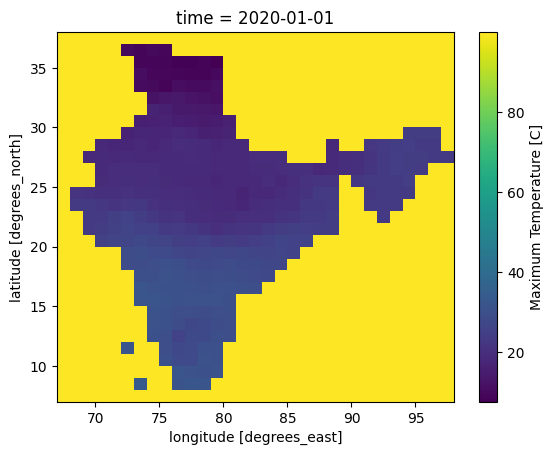

In [35]:
tmax_data.isel(time=0)['tmax'].plot()

In [37]:
(era5_test.sel(time='2020-01-02')['2m_temperature'].sel(latitude=slice(6, 37), longitude=slice(68, 98)).values - modified_era5.sel(time='2020-01-02')['2m_temperature'].sel(latitude=slice(6, 37), longitude=slice(68, 98)).values).flatten().sum()

np.float64(-2535.9850703251723)

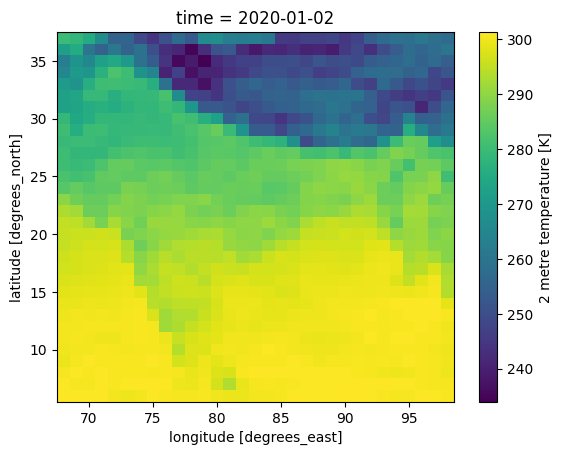

In [41]:
era5_test.sel(time='2020-01-02')['2m_temperature'].sel(latitude=slice(6, 37), longitude=slice(68, 98)).isel(time=0).plot()

In [44]:
modified_era5.nbytes

658202102268

In [ ]:
modified_era5.to_netcdf('/Datastorage/saptarishi.dhanuka_asp25/imd_era5_2015_2022-07-31T18_1deg_37levels_imd_replaced.nc')